In [1]:
from google.colab.patches import cv2_imshow
from google.colab import drive
import numpy as np
import cv2
import matplotlib.pyplot as plt
drive.mount('/content/gdrive')

Mounted at /content/gdrive


(183, 275, 3)
(183, 275)


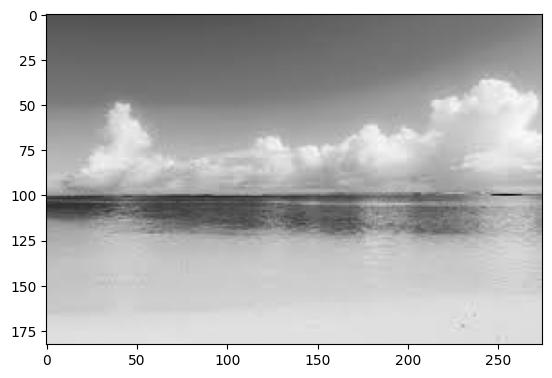

In [2]:
img = cv2.imread('/content/gdrive/My Drive/IP/Ch01/sea.jpg')
print(img.shape)
gimg1 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gimg1.shape)
plt.imshow(gimg1, cmap='gray')

In [3]:
def saturation(val):
  if val > 255:
    return 255
  elif val < 0:
    return 0
  else:
    return val

In [4]:
gPoint = np.zeros((gimg1.shape[0], gimg1.shape[1]), dtype=np.ubyte)

역 변환 실습

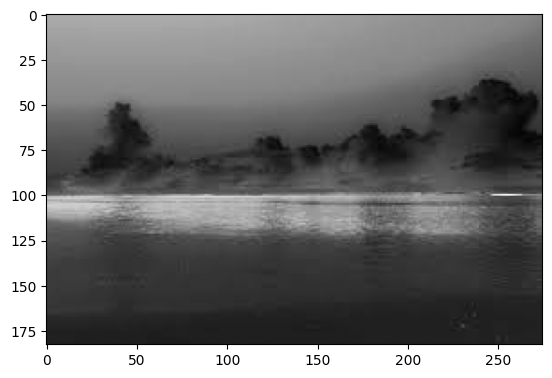

In [6]:
for h in range(gimg1.shape[0]):
  for w in range(gimg1.shape[1]):
    pointVal = 255 - np.int32(gimg1[h,w])
    gPoint[h,w] = saturation(pointVal)

plt.imshow(gPoint, cmap='gray')

이진화

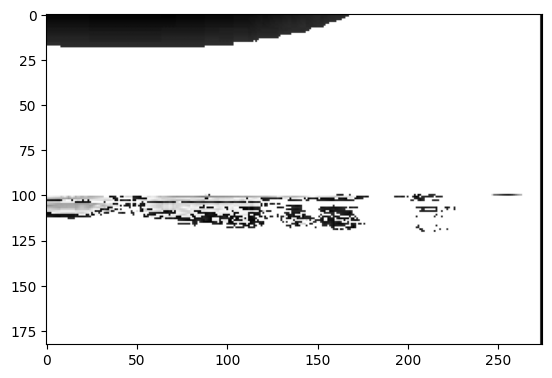

In [20]:
th = 100

for h in range(gimg1.shape[0]):
  for w in range(gimg1.shape[1]):
   if gimg1[h,w] > th:
    gPoint[h,w] = 255
  else:
    gPoint[h,w] = 0

plt.imshow(gPoint, cmap='gray')

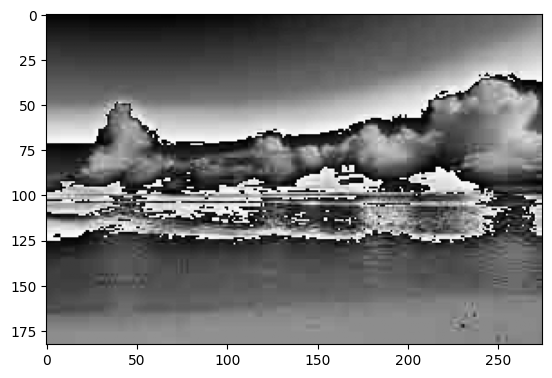

In [21]:
numOfClip = 3
modVal = 255 // numOfClip


for h in range(gimg1.shape[0]):
  for w in range(gimg1.shape[1]):
    pointVal = np.int32(gimg1[h,w]) % modVal
    gPoint[h,w] = saturation(pointVal * numOfClip)

plt.imshow(gPoint, cmap='gray', vmin=0, vmax=255)